In [1]:
import tensorflow as tf


In [2]:
# other imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# get the data
!wget https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv

--2025-03-18 11:50:42--  https://raw.githubusercontent.com/lazyprogrammer/machine_learning_examples/master/tf2.0/moore.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2302 (2.2K) [text/plain]
Saving to: ‘moore.csv’

moore.csv           100%[===================>]   2.25K  --.-KB/s    in 0s      

2025-03-18 11:50:43 (25.8 MB/s) - ‘moore.csv’ saved [2302/2302]



In [4]:
!head moore.csv

1971,2300
1972,3500
1973,2500
1973,2500
1974,4100
1974,4500
1974,8000
1975,3510
1976,5000
1976,8500


In [5]:
# load in the data
data = pd.read_csv('moore.csv', header=None).to_numpy()

In [6]:
data

array([[       1971,        2300],
       [       1972,        3500],
       [       1973,        2500],
       [       1973,        2500],
       [       1974,        4100],
       [       1974,        4500],
       [       1974,        8000],
       [       1975,        3510],
       [       1976,        5000],
       [       1976,        8500],
       [       1976,        6500],
       [       1978,        9000],
       [       1978,       29000],
       [       1979,       17500],
       [       1979,       29000],
       [       1979,       68000],
       [       1981,       11500],
       [       1982,       55000],
       [       1982,      134000],
       [       1983,       22000],
       [       1984,       63000],
       [       1984,      190000],
       [       1985,      275000],
       [       1985,       25000],
       [       1985,       16000],
       [       1986,      110000],
       [       1986,      375000],
       [       1986,       30000],
       [       1987,

In [7]:
X = data[:,0].reshape(-1,1)# makinh an N x D
Y = data[:,1]

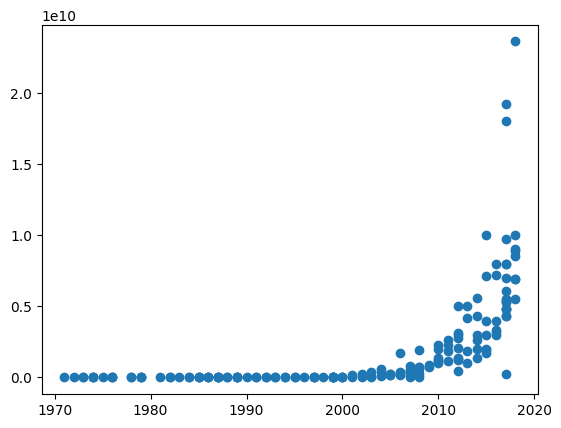

In [8]:
# Plot the data
plt.scatter(X,Y)
plt.show()

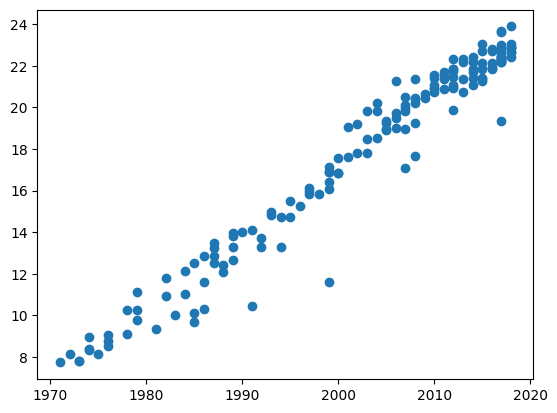

In [9]:
Y = np.log(Y)
plt.scatter(X,Y)
plt.show()

In [10]:
X = X - X.mean()

In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    loss='mse'
)

In [13]:
def schedule(epoch, lr):
    if epoch >= 50:
      return 0.0001
    return 0.001


scheduler = tf.keras.callbacks.LearningRateScheduler(schedule)

In [14]:
r = model.fit(X, Y, epochs=200,callbacks=[scheduler])

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 456.6725 - learning_rate: 0.0010
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 367.6279 - learning_rate: 0.0010
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 279.6194 - learning_rate: 0.0010
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 203.4280 - learning_rate: 0.0010
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 184.7770 - learning_rate: 0.0010
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 147.4773 - learning_rate: 0.0010
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 88.8964 - learning_rate: 0.0010
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 66.1264 - learning_rate: 0.0010
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 52.6909 - learning_rate: 0.0010
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37.9004 - learning_rate: 0.0010
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31.4553 - learning_rate: 0.0010
Epoch 1

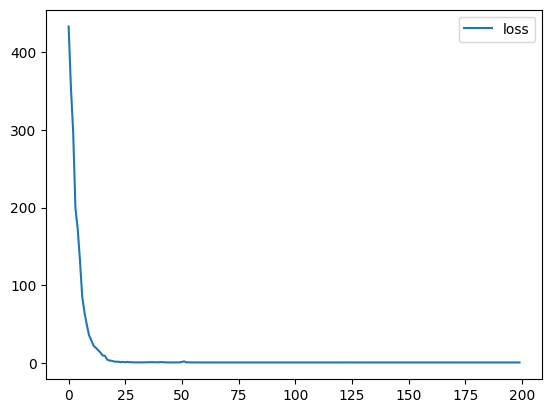

In [15]:
# Plot loss
plt.plot(r.history['loss'], label='loss')
plt.legend()

In [16]:
model.layers

[<Dense name=dense, built=True>]

In [17]:
model.layers[0].get_weights()

[array([[0.33468983]], dtype=float32), array([17.762127], dtype=float32)]

In [18]:
a = model.layers[0].get_weights()[0][0,0]
a

np.float32(0.33468983)

In [19]:
print("Tİme to double:",np.log(2)/a)

Tİme to double: 2.0710135988106497


In [20]:
X = X.flatten()
denominator = X.dot(X) - X.mean() * X.sum()
a = (X.dot(Y) - Y.mean() * X.sum()) / denominator
b = (Y.mean() * X.dot(X) - X.mean() * X.dot(Y)) / denominator
print(a,b)

0.341682487387313 17.764939393631764


# Part 2: Making Predictions

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


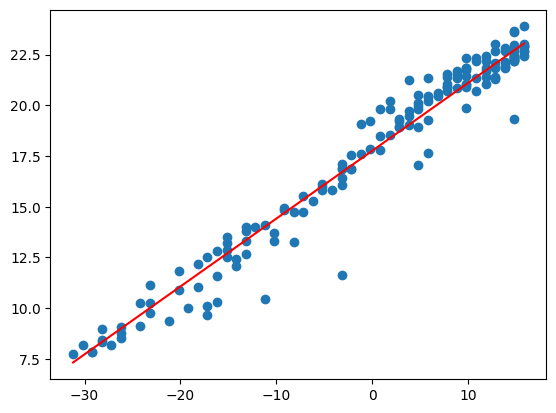

In [21]:
# Make sure the line fits our data
Yhat = model.predict(X).flatten()
plt.scatter(X,Y)
plt.plot(X,Yhat,color='red')
plt.show()

In [22]:
# Manual calculation

# Get the weights
w,b = model.layers[0].get_weights()

# Reshape X because we flattened it again earlier
X = X.reshape(-1,1)

# (N x 1) x (1 x 1) + (1) --> (N x 1)
Yhat2 = (X.dot(w) + b).flatten()

# Don't use == for floating points
np.allclose(Yhat, Yhat2)

True